# PLS Regression — interpretação dos resultados

**Etapa:** leitura do modelo especialista

Reunimos coeficientes padronizados, VIP Scores, permutation importance e desempenho de validação e teste.

**Entrada:** artefatos congelados do PLS  
**Resultado principal:** interpretação das features e dos 11 componentes


## 1. Importações, caminhos e funções

In [1]:
from pathlib import Path
import hashlib, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from IPython.display import display

warnings.filterwarnings("ignore")
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "bases/grupo5/gold_daily_modeling.csv").exists())
BASE_PATH = ROOT / "bases/grupo5/gold_daily_modeling.csv"
OUT = ROOT / "analyses/grupo5/outputs"
OUT.mkdir(parents=True, exist_ok=True)
PROTOCOL_PATH = OUT / "protocol.json"
SEED = 42
np.random.seed(SEED)

def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

def load_data():
    df = pd.read_csv(BASE_PATH, parse_dates=["DATE"]).sort_values("DATE").reset_index(drop=True)
    raw_path = ROOT / "bases/grupo5-tratamento/gold_daily_prices.csv"
    raw = pd.read_csv(raw_path, sep=None, engine="python", parse_dates=["DATE"])
    raw["EXPECTED_TARGET"] = pd.to_numeric(raw["VALUE"], errors="coerce").shift(-1)
    raw["TARGET_DATE"] = raw["DATE"].shift(-1)
    target_lookup = raw[["DATE", "TARGET_DATE", "EXPECTED_TARGET"]]
    df = df.merge(target_lookup, on="DATE", how="left", validate="one_to_one")
    assert df["DATE"].is_monotonic_increasing and not df["DATE"].duplicated().any()
    assert "TARGET_UP" not in df.columns and not df.isna().any().any()
    assert np.allclose(df["TARGET"], df["EXPECTED_TARGET"])
    return df.drop(columns="EXPECTED_TARGET")



In [2]:
def load_protocol(require_data_decisions=False):
    if not PROTOCOL_PATH.exists():
        raise RuntimeError("DECISÃO NECESSÁRIA: execute 01_documentacao_bases.ipynb primeiro.")
    protocol = json.loads(PROTOCOL_PATH.read_text(encoding="utf-8"))
    if protocol.get("protocol_version") != 2:
        raise RuntimeError("Protocolo desatualizado: execute novamente 01_documentacao_bases.ipynb.")
    if protocol["dataset_sha256"] != sha256(BASE_PATH):
        raise RuntimeError("A base congelada não corresponde ao hash do protocolo.")
    if require_data_decisions:
        missing = [k for k in ("source", "unit", "cleaning", "features", "seasonal_period") if not protocol["decisions"].get(k)]
        if missing:
            raise RuntimeError(f"DECISÃO NECESSÁRIA: complete as decisões {missing} antes de modelar.")
    return protocol

def save_protocol(protocol):
    PROTOCOL_PATH.write_text(json.dumps(protocol, indent=2, ensure_ascii=False), encoding="utf-8")

def origins(protocol, split):
    return protocol["origins"][split]

def target_dates(df, origin_ids):
    return df["TARGET_DATE"].iloc[origin_ids].to_numpy()


## 2. Coeficientes, VIP e desempenho

,dataset,model,feature,native_importance,standardized_coefficient,vip_score,permutation_mean,permutation_std,split,is_external,abs_standardized_coefficient
0,gold,PLS_Regression,GOLD_PRICE,140.207141,140.207141,1.500274,347.965386,13.465087,test_final_post_selection,False,140.207141
7,gold,PLS_Regression,GOLD_LAG_1,15.968976,15.968976,1.499292,30.900907,1.403302,test_final_post_selection,False,15.968976
10,gold,PLS_Regression,GOLD_ROLLING_MEAN_5,4.621253,-4.621253,1.497909,5.326437,0.399291,test_final_post_selection,False,4.621253
8,gold,PLS_Regression,GOLD_LAG_5,2.383091,2.383091,1.495768,1.468209,0.210502,test_final_post_selection,False,2.383091
9,gold,PLS_Regression,GOLD_LAG_20,1.788625,-1.788625,1.485496,0.978443,0.150097,test_final_post_selection,False,1.788625
11,gold,PLS_Regression,GOLD_ROLLING_STD_5,0.193893,-0.193893,0.774728,0.014091,0.020936,test_final_post_selection,False,0.193893
1,gold,PLS_Regression,TREASURY_10Y,0.135387,-0.135387,0.343462,0.001584,0.001232,test_final_post_selection,True,0.135387
6,gold,PLS_Regression,MONTH_COS,0.024944,0.024944,0.087602,0.000542,0.001137,test_final_post_selection,False,0.024944
5,gold,PLS_Regression,MONTH_SIN,0.020840,-0.020840,0.063648,-0.000429,0.000873,test_final_post_selection,False,0.020840
2,gold,PLS_Regression,FED_FUNDS_RATE,0.105097,0.105097,0.275420,-0.000480,0.002593,test_final_post_selection,True,0.105097


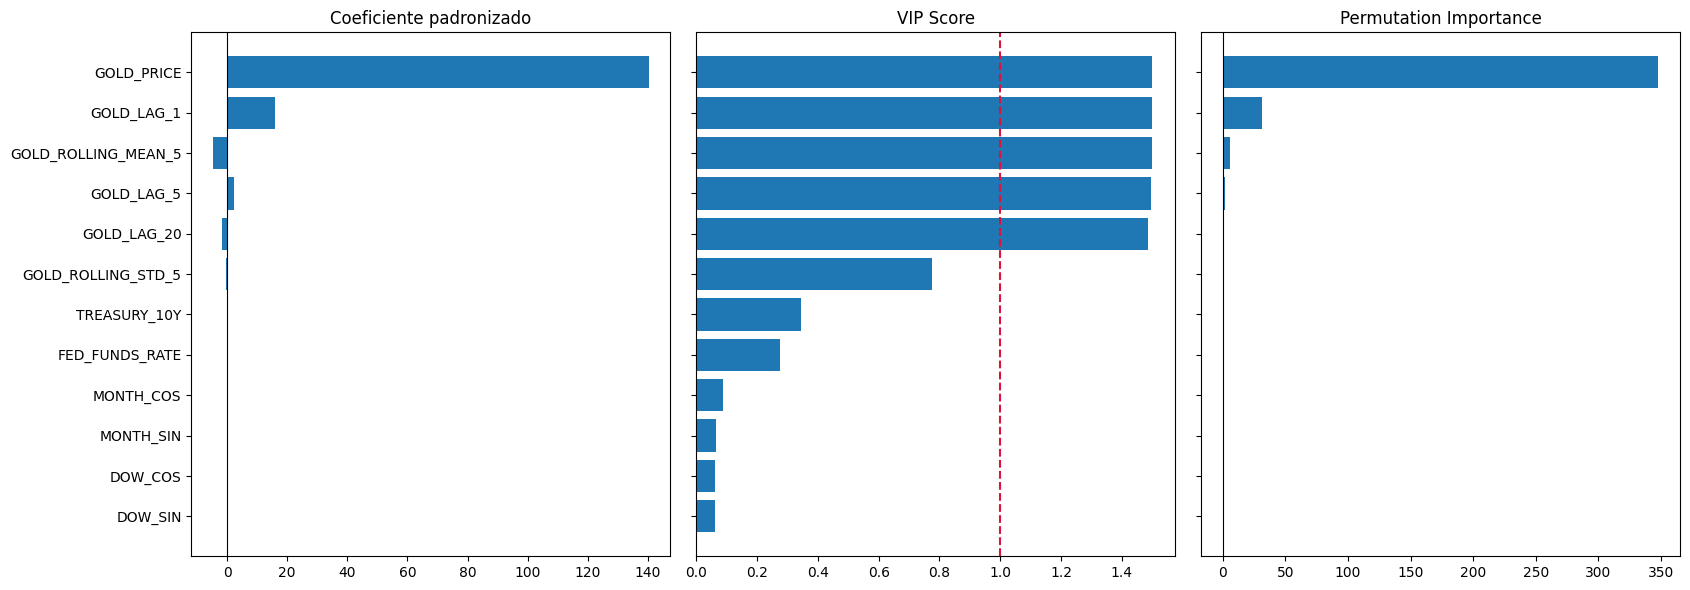

In [3]:
from IPython.display import Markdown, display

protocol = load_protocol(require_data_decisions=True)
importance = pd.read_csv(OUT / "feature_importance.csv")
metrics = pd.read_csv(OUT / "metrics.csv").sort_values("mae")
tuning = pd.read_csv(OUT / "tuning_candidates_PLS_Regression.csv")

pls = (
    importance[importance["model"] == "PLS_Regression"]
    .copy()
    .sort_values("permutation_mean", ascending=False)
)
if pls.empty:
    raise RuntimeError("As importâncias do PLS ainda não foram calculadas.")

pls["is_external"] = pls["feature"].isin(["TREASURY_10Y", "FED_FUNDS_RATE"])
pls["abs_standardized_coefficient"] = pls["standardized_coefficient"].abs()
pls.to_csv(OUT / "pls_feature_interpretation.csv", index=False)
display(pls)

ordered = pls.sort_values("vip_score")
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
axes[0].barh(ordered["feature"], ordered["standardized_coefficient"])
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Coeficiente padronizado")
axes[1].barh(ordered["feature"], ordered["vip_score"])
axes[1].axvline(1, color="crimson", linestyle="--")
axes[1].set_title("VIP Score")
axes[2].barh(ordered["feature"], ordered["permutation_mean"])
axes[2].axvline(0, color="black", linewidth=0.8)
axes[2].set_title("Permutation Importance")
plt.tight_layout()
plt.savefig(OUT / "pls_feature_interpretation.png", dpi=150, bbox_inches="tight")
plt.show()

validation_winner = json.loads(tuning.iloc[0]["parameters"])["n_components"]
test_rank = int(metrics.reset_index(drop=True).query("model == 'PLS_Regression'").index[0] + 1)
pls_test_mae = float(metrics.loc[metrics["model"] == "PLS_Regression", "mae"].iloc[0])
sarimax_test_mae = float(metrics.loc[metrics["model"] == "SARIMAX", "mae"].iloc[0])



In [4]:
display(
    Markdown(
        f"""
## Leitura final do PLS

- A validação selecionou **{validation_winner} componentes**; essa decisão permaneceu congelada.
- No teste, o PLS ficou na posição **{test_rank}**, com MAE **{pls_test_mae:.4f}**.
- O SARIMAX obteve MAE **{sarimax_test_mae:.4f}**; a diferença absoluta para o PLS foi apenas **{abs(pls_test_mae - sarimax_test_mae):.4f}**.

Vencer na validação e ficar aproximadamente em terceiro no teste não é contradição. Os períodos têm níveis e regimes diferentes, e as diferenças entre os três primeiros modelos são pequenas. O resultado reflete variabilidade amostral e generalização fora do intervalo usado no tuning, não autorização para alterar os 11 componentes.

Coeficientes padronizados mostram direção e magnitude dentro do modelo linear. VIP resume a participação da feature nos componentes supervisionados. Permutation Importance mede perda de desempenho quando a feature é embaralhada. Nenhuma dessas medidas prova causalidade, e a multicolinearidade pode repartir importância entre preço atual, lags e médias móveis.
"""
    )
)

display(
    pls[pls["is_external"]][
        ["feature", "standardized_coefficient", "vip_score", "permutation_mean"]
    ]
)



## Leitura final do PLS

- A validação selecionou **11 componentes**; essa decisão permaneceu congelada.
- No teste, o PLS ficou na posição **3**, com MAE **11.6002**.
- O SARIMAX obteve MAE **11.5988**; a diferença absoluta para o PLS foi apenas **0.0014**.

Vencer na validação e ficar aproximadamente em terceiro no teste não é contradição. Os períodos têm níveis e regimes diferentes, e as diferenças entre os três primeiros modelos são pequenas. O resultado reflete variabilidade amostral e generalização fora do intervalo usado no tuning, não autorização para alterar os 11 componentes.

Coeficientes padronizados mostram direção e magnitude dentro do modelo linear. VIP resume a participação da feature nos componentes supervisionados. Permutation Importance mede perda de desempenho quando a feature é embaralhada. Nenhuma dessas medidas prova causalidade, e a multicolinearidade pode repartir importância entre preço atual, lags e médias móveis.


,feature,standardized_coefficient,vip_score,permutation_mean
1,TREASURY_10Y,-0.135387,0.343462,0.001584
2,FED_FUNDS_RATE,0.105097,0.275420,-0.000480


## Validação x Teste

O PLS venceu na validação e ficou em terceiro no teste. A diferença para o SARIMAX foi de aproximadamente 0,0014 de MAE, portanto o desempenho foi praticamente equivalente. O teste não alterou os 11 componentes escolhidos.

In [ ]:
# Validação e teste usam períodos diferentes
hyperparameters = pd.read_csv(OUT / "hyperparameters.csv")
metrics = pd.read_csv(OUT / "metrics.csv")
pls_validation = hyperparameters.loc[hyperparameters["model"] == "PLS_Regression", "validation_mae"].iloc[0]
pls_test = metrics.loc[metrics["model"] == "PLS_Regression", "mae"].iloc[0]
sarimax_test = metrics.loc[metrics["model"] == "SARIMAX", "mae"].iloc[0]
validation_test = pd.DataFrame(
    [
        {"medida": "PLS — MAE de validação", "valor": pls_validation},
        {"medida": "PLS — MAE de teste", "valor": pls_test},
        {"medida": "SARIMAX — MAE de teste", "valor": sarimax_test},
        {"medida": "diferença PLS - SARIMAX no teste", "valor": pls_test - sarimax_test},
    ]
)
display(validation_test)

medida,valor
PLS — MAE de validação,2.970125
PLS — MAE de teste,11.600212
SARIMAX — MAE de teste,11.598841
diferença PLS - SARIMAX no teste,0.001371


## Interpretação

O PLS venceu na validação e ficou em terceiro no teste, apenas 0,0014 de MAE atrás do SARIMAX. A diferença é praticamente nula e não altera a escolha de 11 componentes.

## Artefatos

Arquivos usados ou produzidos nesta etapa:

- `outputs/pls_feature_interpretation.csv`
- `outputs/pls_feature_interpretation.png`
- `outputs/feature_importance_summary.csv`